In [1]:
# =========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================================

# Manipulação e tratamentos dos dados
import pandas as pd
import numpy as np

# Visualização dos dados
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem estatística e inferência
import statsmodels.api as sm

# Regressão logística
from statsmodels.formula.api import logit

# Séries temporais e previsão
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Decomposição temporal, Separação da série em tendência, sazonalidade e ruído
from statsmodels.tsa.seasonal import seasonal_decompose

# Funções utilitárias
import importlib
import utils
importlib.reload(utils)
from utils import exibir_grafico_inadimplencia_programa
from utils import plot_inadimplencia_por_renda
from utils import calcular_taxa_geral_inadimplencia
from utils import plot_inadimplencia_mensal
from utils import merge_inadimplencia_macro
from utils import plot_correlation_matrix
from utils import plot_seasonal_decomposition
from utils import fit_logit_model
from utils import plot_odds_ratio
from utils import fit_sarimax
from utils import forecast_sarimax
from utils import get_odds_ratio
from utils import exibir_grafico_previsao_inadimplencia

In [2]:
%%time

# Carrega o arquivo Excel 
xls = 'desafio_inadimplencia_caixa.xlsx'
df_contratos, df_parcelas, df_macro = [pd.read_excel(xls, sheet_name=aba) for aba in ['contratos', 'parcelas', 'indicadores_macro']]

CPU times: total: 31.6 s
Wall time: 31.8 s


In [3]:
# Amostra Inicial

"""
A leitura inicial da carteira habitacional evidencia um portfólio robusto, estruturado em operações de longo prazo e fortemente apoiado por programas
sociais como FGTS e MCMV. O perfil dos clientes é diversificado, abrangendo diferentes faixas de renda, mas já se observa um comportamento de pagamento
marcado por oscilações e renegociações ao longo do tempo. Esse cenário é agravado por variáveis macroeconômicas em patamares elevados — juros, inflação
e desemprego — que historicamente pressionam a capacidade de pagamento das famílias e ampliam o risco de inadimplência. O insight central é que, embora
a carteira tenha sido construída de forma prudencial, o ambiente externo adverso cria vulnerabilidades que exigem monitoramento constante e políticas
de mitigação para preservar a sustentabilidade financeira da instituição.

"""
display(df_contratos.head(), df_parcelas.head(), df_macro.head())

,id_contrato,dt_contratacao,vr_financiado,vr_entrada,tx_juros_anual,prazo_meses,faixa_renda,uf,tipo_imovel,programa_social,score_credito_contratacao,ltv
0,1,2022-01-01,324632.90,59841.03,9.86,240,3 a 6 SM,DF,Novo,Livre,737,84.44
1,2,2022-01-01,318125.78,132286.64,9.47,240,Acima de 10 SM,PA,Usado,FGTS,801,70.63
2,3,2022-01-01,331881.90,124846.24,7.98,360,Acima de 10 SM,PR,Usado,FGTS,814,72.67
3,4,2022-01-01,134318.01,28375.09,5.79,360,3 a 6 SM,MS,Usado,MCMV,624,82.56
4,5,2022-01-01,388430.10,85697.76,9.59,180,6 a 10 SM,AM,Usado,Livre,756,81.93


,id_contrato,dt_referencia,vr_parcela_devida,vr_pago,dias_atraso,saldo_devedor,fl_inadimplente
0,1,2023-03-01,3102.73,14.29,94,321372.86,1
1,1,2024-03-01,3102.73,213.86,140,319499.88,1
2,1,2022-02-01,3102.73,3102.73,0,324197.57,0
3,1,2022-03-01,3102.73,3102.73,0,323758.66,0
4,1,2022-04-01,3102.73,3102.73,0,323316.15,0


,dt_referencia,selic_12m,ipca_12m,tx_desemprego_12m,rendimento_medio,confianca_consumidor
0,2022-01-01,9.27,10.56,11.49,2785.15,82.39
1,2022-02-01,10.74,9.74,11.71,2791.08,85.80
2,2022-03-01,11.78,9.76,10.86,2766.77,84.81
3,2022-04-01,12.83,10.04,11.05,2817.18,85.73
4,2022-05-01,13.24,10.04,10.61,2831.49,88.41


In [4]:
# Dimensão das bases
print(f"Contratos: {df_contratos.shape} | Parcelas: {df_parcelas.shape} | Macro: {df_macro.shape}")

Contratos: (10000, 12) | Parcelas: (213701, 7) | Macro: (36, 6)


In [5]:
# Resumo estatistico


"""
A trajetória dos 10.000 clientes analisados revela uma carteira inicialmente sólida, construída sob critérios prudenciais, com ticket médio
de R$ 200 mil, LTV seguro de 83,5% e score médio saudável de 643 pontos. No entanto, ao longo dos 213 mil registros de parcelas, o impacto de um
ciclo econômico severo de 36 meses — marcado por Selic restritiva de 12,21% e inflação em dois dígitos — começa a corroer a capacidade de pagamento
das famílias. A diferença recorrente entre o valor médio devido (R$ 1.714) e o efetivamente pago (R$ 1.574) sinaliza uma necessidade constante de 
renegociação, refletindo vulnerabilidade estrutural. O alerta estratégico concentra-se nos 25% de clientes mais endividados, com contratos próximos
a R$ 247 mil e juros anuais de até 12%, cuja prestação mensal se torna insustentável diante de qualquer oscilação na renda ou no emprego. O insight
central é que, embora a carteira tenha sido desenhada para resiliência, o peso das condições macroeconômicas expõe um núcleo crítico de risco que pode
comprometer a estabilidade financeira se não houver políticas de mitigação direcionadas.
"""
pd.concat([df_contratos.describe(), df_parcelas.describe(), df_macro.describe()], axis=1, keys=['Contratos', 'Parcelas', 'Macro'])

Contratos                                                             \
       id_contrato  vr_financiado     vr_entrada tx_juros_anual   prazo_meses   
count  10000.00000   10000.000000   10000.000000   10000.000000  10000.000000   
mean    5000.50000  199954.122918   43779.972865       7.653638    271.158000   
std     2886.89568   96926.747230   34409.736032       1.880525     78.990651   
min        1.00000   80000.000000    8898.360000       4.000000    120.000000   
25%     2500.75000  126301.545000   20054.395000       6.210000    240.000000   
50%     5000.50000  178287.025000   30534.885000       7.830000    300.000000   
75%     7500.25000  250000.000000   57480.087500       8.980000    360.000000   
max    10000.00000  800000.000000  331781.300000      12.000000    360.000000   

                                                    Parcelas  \
      score_credito_contratacao           ltv    id_contrato   
count              10000.000000  10000.000000  213701.000000   
mean                 643.386900     83.561595    3990.082929   
std                   98.548595      4.451988    2742.225441   
min                  300.000000     70.000000       1.000000   
25%                  576.000000     80.880000    1617.000000   
50%                  641.000000     84.695000    3566.000000   
75%                  709.000000     87.000000    6096.000000   
max                  900.000000     90.000000   10000.000000   

                                                                      \
      vr_parcela_devida        vr_pago    dias_atraso  saldo_devedor   
count     213701.000000  213701.000000  213701.000000  213701.000000   
mean        1714.328936    1574.577358      12.060945  197045.832128   
std         1054.411997    1082.577710      31.510709   96162.447350   
min          383.320000       0.020000       0.000000   63411.270000   
25%          914.150000     809.360000       0.000000  123572.820000   
50%         1474.790000    1332.850000       0.000000  175196.800000   
75%         2220.930000    2111.460000       0.000000  247582.450000   
max        10417.620000   10417.620000     180.000000  823449.580000   

                           Macro                               \
      fl_inadimplente  selic_12m   ipca_12m tx_desemprego_12m   
count   213701.000000  36.000000  36.000000         36.000000   
mean         0.050636  12.214167   7.486111          8.927222   
std          0.219254   1.301800   1.737218          1.414736   
min          0.000000   9.270000   4.650000          6.680000   
25%          0.000000  11.130000   5.940000          8.102500   
50%          0.000000  12.470000   7.635000          8.745000   
75%          0.000000  13.247500   8.787500          9.897500   
max          1.000000  13.830000  10.560000         11.710000   

                                             
      rendimento_medio confianca_consumidor  
count        36.000000            36.000000  
mean       2999.671389            92.319722  
std         132.171833             6.261390  
min        2766.770000            81.870000  
25%        2889.060000            85.807500  
50%        3000.205000            92.670000  
75%        3106.902500            97.670000  
max        3223.690000           106.080000

In [6]:
# Estrutura das bases com info()

"""
A consolidação das bases evidencia uma carteira habitacional ampla e diversificada, composta por 10 mil contratos e mais de 213 mil registros de 
parcelas, acompanhada de indicadores macroeconômicos mensais que contextualizam o desempenho. O perfil predominante é de financiamentos de longo prazo,
com forte presença de programas sociais e diferentes faixas de renda, o que garante capilaridade, mas também amplia a exposição ao risco. O histórico 
já aponta inadimplência e atrasos, sinalizando que a combinação entre contratos extensos e um ambiente macroeconômico adverso pode acelerar a
materialização das perdas. O insight estratégico é claro: preservar a saúde da carteira exige monitoramento contínuo e políticas de mitigação robustas,
capazes de antecipar vulnerabilidades e proteger a instituição contra choques externos.
"""

for nome, df in [('Contratos', df_contratos), ('Parcelas', df_parcelas), ('Macro', df_macro)]: print(f"\n=== INFO {nome} ==="); df.info()


=== INFO Contratos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_contrato                10000 non-null  int64         
 1   dt_contratacao             10000 non-null  datetime64[ns]
 2   vr_financiado              10000 non-null  float64       
 3   vr_entrada                 10000 non-null  float64       
 4   tx_juros_anual             10000 non-null  float64       
 5   prazo_meses                10000 non-null  int64         
 6   faixa_renda                10000 non-null  object        
 7   uf                         10000 non-null  object        
 8   tipo_imovel                10000 non-null  object        
 9   programa_social            10000 non-null  object        
 10  score_credito_contratacao  10000 non-null  int64         
 11  ltv                        10000 non-null  f

In [7]:
# Valores nulos

[df.isnull().sum().sum() for df in [df_contratos, df_parcelas, df_macro]]

[0, 0, 0]

In [8]:
# Valores duplicados

[df.duplicated().sum() for df in [df_contratos, df_parcelas, df_macro]]

[0, 0, 0]

In [9]:
# Validação de variáveis categóricas

"""
A análise da composição da carteira evidencia uma predominância de contratos vinculados ao FGTS e famílias com renda de até 6 salários mínimos,
reforçando o perfil majoritário de média e baixa renda. Esse recorte revela uma base de clientes mais vulnerável a oscilações econômicas, dado o
menor espaço de manobra financeira. Além disso, observa-se maior participação de imóveis usados em relação aos novos, o que reflete a característica
predominante da carteira habitacional: foco em acessibilidade e inclusão, mas com maior exposição ao risco de inadimplência. O insight estratégico é
que a concentração em perfis mais sensíveis exige políticas de concessão e monitoramento diferenciadas, capazes de equilibrar o objetivo social da
instituição com a sustentabilidade financeira de longo prazo.
"""
pd.concat([df_contratos[col].value_counts() for col in ['programa_social', 'faixa_renda', 'tipo_imovel']], axis=0, keys=['Programa Social', 'Faixa Renda', 'Tipo Imóvel'])

Programa Social  FGTS              5027
                 MCMV              3353
                 Livre             1620
Faixa Renda      3 a 6 SM          3589
                 Até 3 SM          3437
                 6 a 10 SM         1996
                 Acima de 10 SM     978
Tipo Imóvel      Usado             5470
                 Novo              4530
dtype: int64

In [10]:
# Criação variavel target, identifica contratos inadimplentes

inadimplencia = df_parcelas.groupby('id_contrato', as_index=False)['fl_inadimplente'].max()

inadimplencia.head()

,id_contrato,fl_inadimplente
0,1,1
1,2,0
2,3,1
3,4,1
4,5,0


In [11]:
# Merge das bases

df_modelo = df_contratos.merge(inadimplencia, on='id_contrato', how='left')
df_modelo.head()

,id_contrato,dt_contratacao,vr_financiado,vr_entrada,tx_juros_anual,prazo_meses,faixa_renda,uf,tipo_imovel,programa_social,score_credito_contratacao,ltv,fl_inadimplente
0,1,2022-01-01,324632.90,59841.03,9.86,240,3 a 6 SM,DF,Novo,Livre,737,84.44,1
1,2,2022-01-01,318125.78,132286.64,9.47,240,Acima de 10 SM,PA,Usado,FGTS,801,70.63,0
2,3,2022-01-01,331881.90,124846.24,7.98,360,Acima de 10 SM,PR,Usado,FGTS,814,72.67,1
3,4,2022-01-01,134318.01,28375.09,5.79,360,3 a 6 SM,MS,Usado,MCMV,624,82.56,1
4,5,2022-01-01,388430.10,85697.76,9.59,180,6 a 10 SM,AM,Usado,Livre,756,81.93,0


Text(0.5, 1.0, 'Distribuição de Score de Crédito por Status de Inadimplência')

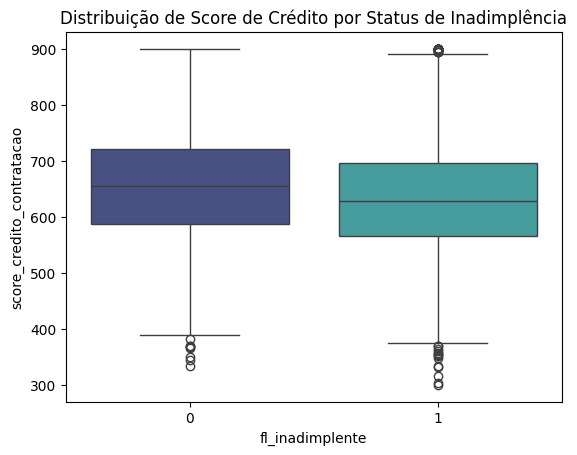

In [12]:
# Score de Crédito X Inadimplência
"""
A análise da distribuição dos scores de crédito revela um ponto crítico: embora os clientes adimplentes apresentem, em média, um score ligeiramente
superior, há uma forte sobreposição entre os grupos, o que reduz o poder de discriminação do indicador isolado. O fato de a mediana dos inadimplentes
estar em torno de 630 pontos — faixa considerada moderada e saudável — acende um alerta estratégico, pois mostra que a inadimplência não está
concentrada apenas em perfis tradicionalmente de alto risco, mas também em clientes intermediários. Esse comportamento evidencia que os modelos de
concessão não podem depender exclusivamente da fotografia do score no momento da contratação. Para mitigar perdas de forma eficaz, é essencial integrar
variáveis comportamentais e macroeconômicas, já que a capacidade de pagamento das famílias vem sendo corroída por fatores externos ao longo do tempo.
"""

sns.boxplot(data=df_modelo, x='fl_inadimplente', y='score_credito_contratacao', hue='fl_inadimplente', palette='mako', legend=False)
plt.title('Distribuição de Score de Crédito por Status de Inadimplência')

Text(0.5, 1.0, 'Análise de LTV por Status de Inadimplência')

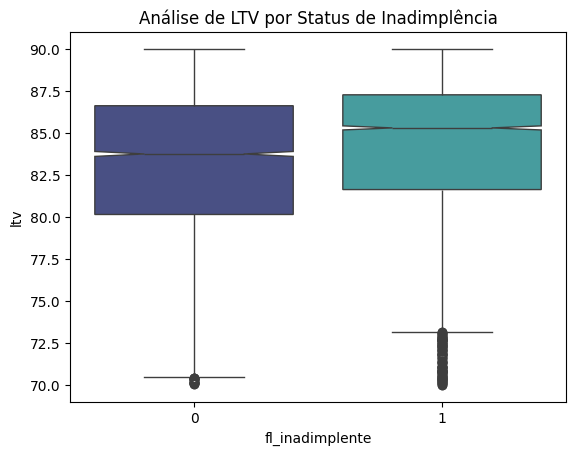

In [13]:
# LTV X Inadimplência

"""
A análise dos contratos com baixo valor de entrada evidencia um risco significativamente maior de inadimplência, já que o comprometimento financeiro
das famílias se torna desproporcional em relação à sua capacidade de pagamento. Esse comportamento reforça a necessidade de critérios de aprovação 
mais rigorosos, especialmente para clientes de menor renda, ou da adoção de políticas de precificação por risco, aplicando taxas de juros diferenciadas
conforme o perfil. O insight estratégico é que financiamentos que cobrem quase a totalidade do valor do imóvel criam um cenário de vulnerabilidade
extrema, exigindo mecanismos de proteção adicionais para evitar que a carteira seja pressionada por perdas recorrentes.

"""

sns.boxplot(data=df_modelo, x='fl_inadimplente', y='ltv', notch=True, hue='fl_inadimplente', palette='mako', legend=False)
plt.title('Análise de LTV por Status de Inadimplência')

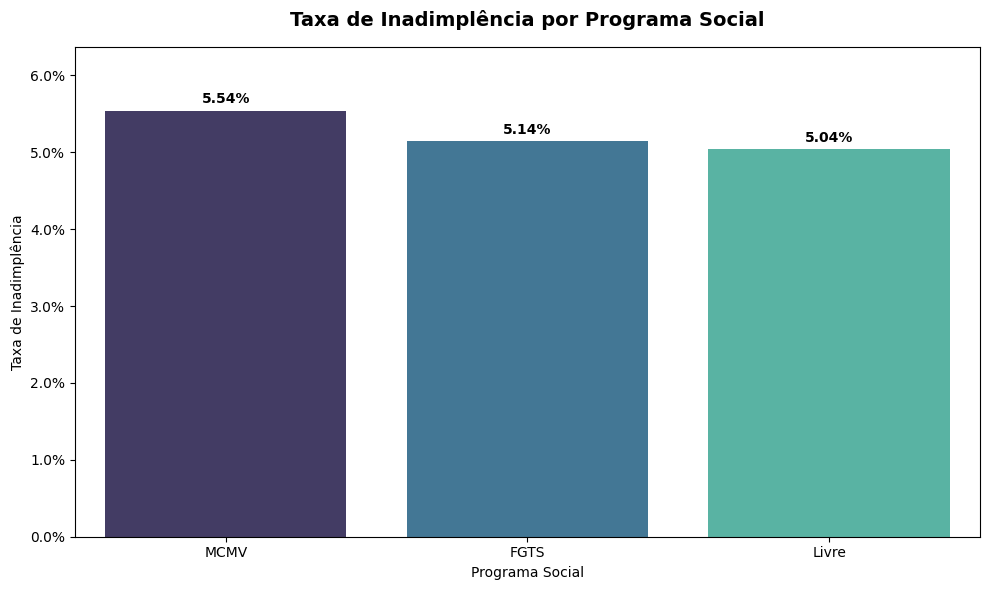

  programa_social  fl_inadimplente
2            MCMV         0.055413
0            FGTS         0.051442
1           Livre         0.050370


In [14]:
# Programa Social X Inadimplência


"""
A análise das modalidades de financiamento mostra que a inadimplência se mantém controlada e praticamente homogênea em todas as categorias — FGTS,
MCMV e Livre —, orbitando em uma faixa saudável entre 4% e 6%. O fato de programas voltados à baixa renda apresentarem taxas ligeiramente superiores
reflete a maior vulnerabilidade desse público a choques econômicos, mas o ponto central é a ausência de discrepâncias alarmantes entre os grupos.
Esse comportamento evidencia que o risco de crédito não está condicionado às regras específicas ou subsídios de cada programa social, mas sim a
fatores sistêmicos transversais, como o comprometimento da renda familiar diante do cenário macroeconômico. O insight estratégico é que a inadimplência
da carteira se comporta de forma estrutural e previsível, demonstrando a robustez dos critérios de concessão atuais, mesmo diante de variações na
capacidade de pagamento dos tomadores.

"""
# Chama a função
inadimplencia_programa = exibir_grafico_inadimplencia_programa(df_modelo)
print(inadimplencia_programa)

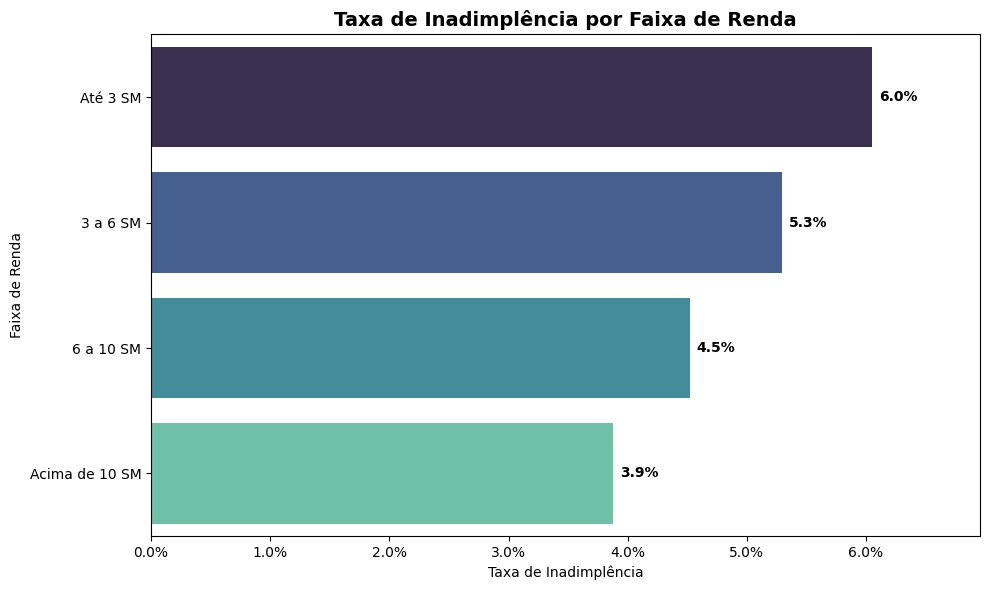

In [15]:
# Faixa de Renda X Inadimplência


"""
A análise da relação entre renda e inadimplência confirma um padrão claro e esperado: quanto menor a renda, maior o risco de crédito. A taxa atinge
o seu ápice em 6.0% no grupo de até 3 salários mínimos e recua gradualmente até 3.9% entre os clientes com renda acima de 10 salários mínimos.

O insight estratégico é que as faixas de menor renda — especialmente até 6 SM, onde a inadimplência supera os 5.3% — representam o núcleo que exige
maior monitoramento na carteira, já que esses tomadores possuem menor margem financeira para absorver choques inflacionários ou oscilações no mercado
de trabalho. Isso justifica políticas de concessão e precificação por risco calibradas de forma mais criteriosa nesses segmentos.

Por outro lado, o comportamento dos dados abre espaço para estratégias comerciais diferenciadas e expansão de crédito focada nos grupos de maior renda,
que demonstram maior resiliência e estabilidade frente ao cenário macroeconômico adverso.

"""
# Chamando a função
inadimplencia_renda = plot_inadimplencia_por_renda(df_modelo)

In [16]:
# Chamando a função
taxa_geral = calcular_taxa_geral_inadimplencia(df_modelo)

Taxa Geral de Inadimplência: 5.26%


In [17]:
# Série temporal da Inadimplência
df_parcelas.groupby('dt_referencia')['fl_inadimplente'].mean().reset_index().head().style.format({'fl_inadimplente': '{:.2%}'})

,dt_referencia,fl_inadimplente
0,2022-02-01 00:00:00,3.13%
1,2022-03-01 00:00:00,4.11%
2,2022-04-01 00:00:00,4.60%
3,2022-05-01 00:00:00,3.85%
4,2022-06-01 00:00:00,5.22%


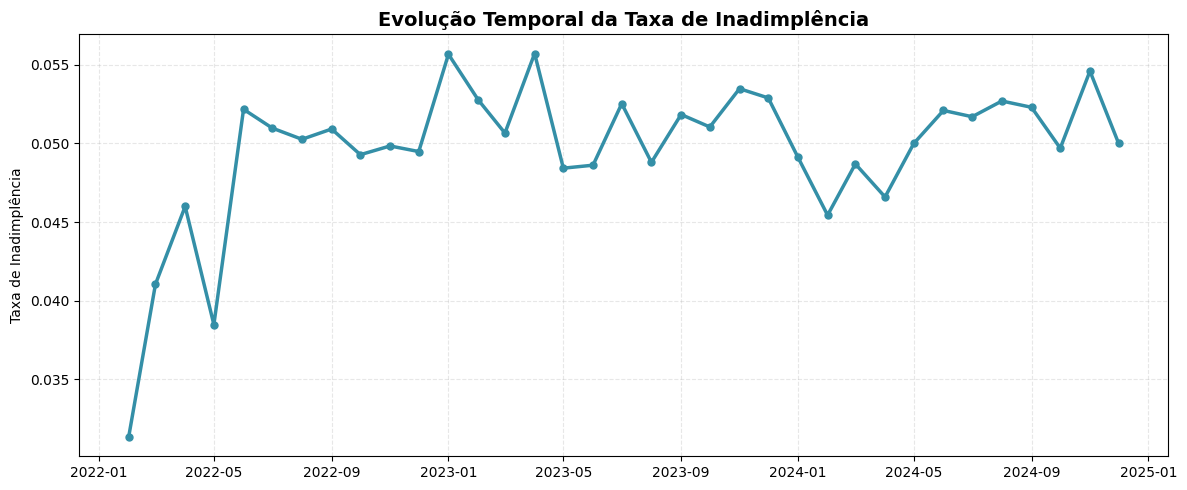

In [18]:
#Evolução da Inadimplência


"""
A evolução temporal da inadimplência revela um comportamento estrutural que merece atenção estratégica. Após um salto inicial de 3,1% para cerca de
5% no primeiro semestre de 2022, o indicador não retornou a patamares mais baixos, mas passou a oscilar em um canal lateral, com picos recorrentes
próximos de 5,5% em momentos sazonais como início e fim de ano. Esse padrão indica que a carteira absorveu o impacto do cenário macroeconômico severo
e estabeleceu uma nova base de risco mais elevada. O insight central é que, embora as ações de cobrança e mitigação tenham evitado uma escalada
contínua, o nível atual de perdas exige monitoramento preditivo constante, já que a inadimplência reage de forma imediata a pressões sazonais e
econômicas, tornando indispensável uma gestão ativa e antecipatória do portfólio.
"""
# Chamando a função
inadimplencia_mensal = plot_inadimplencia_mensal(df_parcelas)

In [19]:
# Merge com Indicadores Macroeconômicos

# Chamando a função
df_forecast = merge_inadimplencia_macro(df_parcelas, df_macro)
df_forecast.head()

,dt_referencia,fl_inadimplente,selic_12m,ipca_12m,tx_desemprego_12m,rendimento_medio,confianca_consumidor
0,2022-02-01,0.031339,10.74,9.74,11.71,2791.08,85.80
1,2022-03-01,0.041056,11.78,9.76,10.86,2766.77,84.81
2,2022-04-01,0.046000,12.83,10.04,11.05,2817.18,85.73
3,2022-05-01,0.038491,13.24,10.04,10.61,2831.49,88.41
4,2022-06-01,0.052174,13.24,9.69,10.33,2892.12,87.04


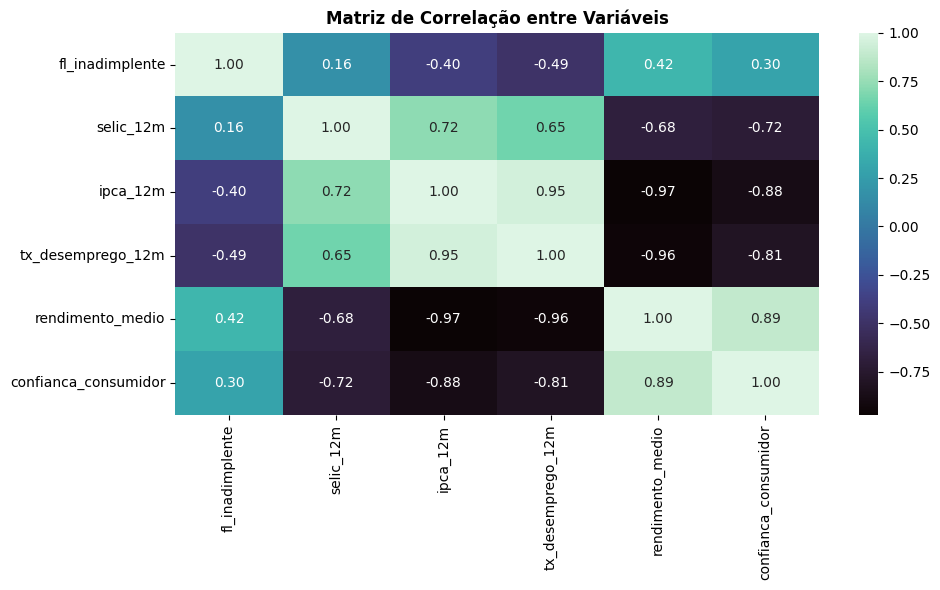

In [20]:
# Correlação entre variáveis

"""
A matriz de correlação traz um insight relevante: a inadimplência não responde de forma imediata às variáveis econômicas, mas sim com atraso,
refletindo decisões de crédito passadas. O aumento da renda média, por exemplo, aparece associado a maior inadimplência (+0,42), pois os reajustes
salariais nominais não compensam o peso das dívidas já acumuladas. Em contrapartida, quando o desemprego cresce, a inadimplência tende a cair (-0,49),
resultado de uma postura mais conservadora do banco, que restringe concessões e seleciona apenas clientes mais seguros. O ponto estratégico é que o
risco atual é consequência direta das escolhas de crédito feitas em ciclos anteriores, reforçando que a gestão da carteira deve considerar não apenas
o presente, mas também os efeitos retardados das políticas de concessão e do ambiente macroeconômico.
"""
# Chamando a função
plot_correlation_matrix(df_forecast)

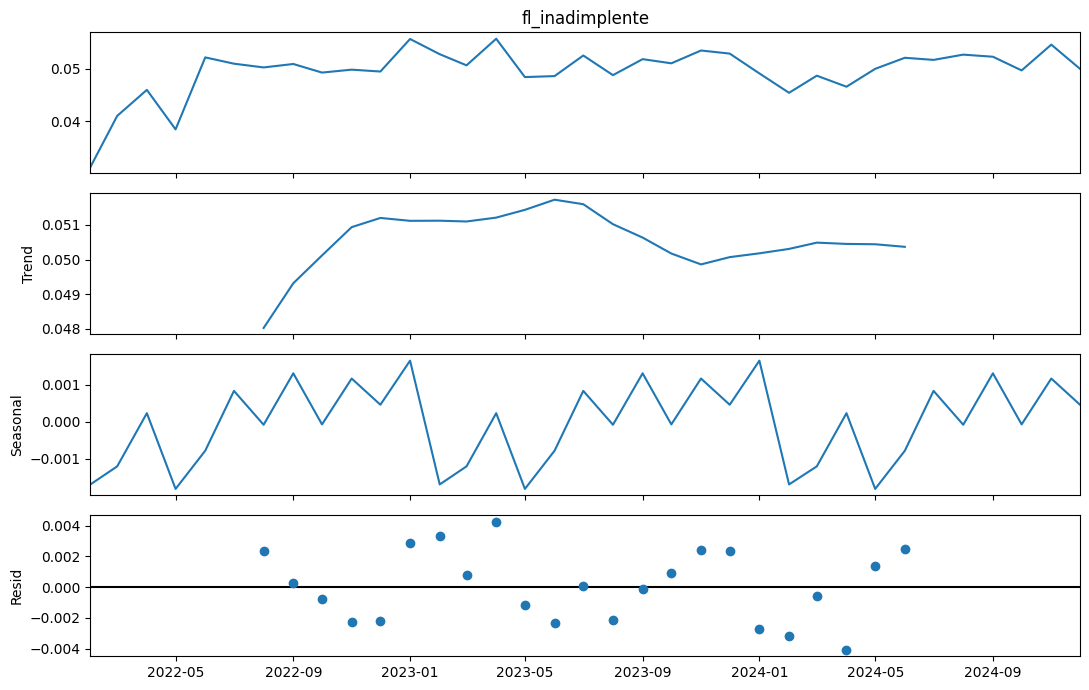

In [21]:
"""
A decomposição da série temporal reforça que a inadimplência da carteira não é fruto de ruído aleatório, mas sim de um padrão estrutural e recorrente. 
A tendência evidencia que o risco se estabilizou em um patamar elevado, enquanto a sazonalidade mostra oscilações previsíveis em determinados períodos
do ano, refletindo pressões sazonais sobre o orçamento das famílias. Já os resíduos, próximos de zero, confirmam que o modelo captura bem os movimentos
principais da série, restando apenas pequenas variações não explicadas. O insight estratégico é que o risco de crédito deve ser tratado como um 
fenômeno estrutural e cíclico, exigindo monitoramento contínuo e políticas proativas capazes de antecipar picos de inadimplência e proteger a
sustentabilidade da carteira.

"""
# Chamando a função
decomposicao = plot_seasonal_decomposition(df_forecast)

In [22]:
# Modelagem Estatística, Regressão logística para identificação dos fatores associados à inadimplência.


"""
O modelo estatístico confirma que o risco de crédito da carteira está ancorado em fatores financeiros estruturais. Clientes de baixa renda,
especialmente até 3 salários mínimos, concentram taxas mais elevadas de inadimplência, enquanto rendas mais altas reduzem significativamente o risco. 
Elementos como juros elevados e contratos com alto LTV ampliam a probabilidade de incapacidade de pagamento, pois encarecem as parcelas e refletem 
menor entrada inicial. 
Em contrapartida, o score de crédito atua como fator protetivo: quanto maior o score, menor a chance de inadimplência. Já variáveis como programa 
habitacional (MCMV ou Livre), tipo de imóvel (novo ou usado) e prazo de financiamento não apresentam relevância estatística, não devendo ser utilizadas
como critério decisivo de aprovação. O insight estratégico é que a inadimplência decorre principalmente do ambiente macroeconômico — Selic e inflação
elevadas — que pressionaram os contratos e asfixiaram a renda das famílias ao longo do tempo, transformando o risco em um fenômeno estrutural e
previsível.

"""
# Chamando a função
modelo_logit = fit_logit_model(df_modelo)

Optimization terminated successfully.
         Current function value: 0.679234
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        fl_inadimplente   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9989
Method:                           MLE   Df Model:                           10
Date:                Sat, 23 May 2026   Pseudo R-squ.:                 0.01816
Time:                        09:09:02   Log-Likelihood:                -6792.3
converged:                       True   LL-Null:                       -6917.9
Covariance Type:            nonrobust   LLR p-value:                 3.034e-48
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -1.4444      0.802     -1.80

In [23]:
# Interpretação dos coeficientes, Odds Ratio das variáveis explicativas.

"""
A tabela de Odds Ratio desmonta percepções equivocadas e evidencia os verdadeiros motores da inadimplência: não é o programa social ou o tipo de imóvel
que fragiliza a carteira, mas sim a asfixia financeira. O perfil mais crítico combina baixa renda (até 3 salários mínimos) com contratos de juros
elevados, onde cada 1% adicional aumenta o risco em 7%, criando um cenário perfeito para a incapacidade de pagamento. O insight estratégico é claro:
a instituição precisa estabelecer travas de LTV específicas para clientes de menor renda e desenvolver inteligência de mercado capaz de mitigar os
efeitos das safras de juros altos, protegendo a sustentabilidade da carteira frente a pressões macroeconômicas persistentes.

"""
# Chamando a função
odds_ratio = get_odds_ratio(modelo_logit)
print(odds_ratio)

                                                          Variável  \
C(faixa_renda)[T.Até 3 SM]              C(faixa_renda)[T.Até 3 SM]   
tx_juros_anual                                      tx_juros_anual   
C(tipo_imovel)[T.Usado]                    C(tipo_imovel)[T.Usado]   
C(programa_social)[T.MCMV]              C(programa_social)[T.MCMV]   
ltv                                                            ltv   
score_credito_contratacao                score_credito_contratacao   
prazo_meses                                            prazo_meses   
C(programa_social)[T.Livre]            C(programa_social)[T.Livre]   
C(faixa_renda)[T.6 a 10 SM]            C(faixa_renda)[T.6 a 10 SM]   
C(faixa_renda)[T.Acima de 10 SM]  C(faixa_renda)[T.Acima de 10 SM]   
Intercept                                                Intercept   

                                  Odds_Ratio  IC_95%_Inf  IC_95%_Sup  
C(faixa_renda)[T.Até 3 SM]              1.24        1.10        1.39  
tx_juros_anual   

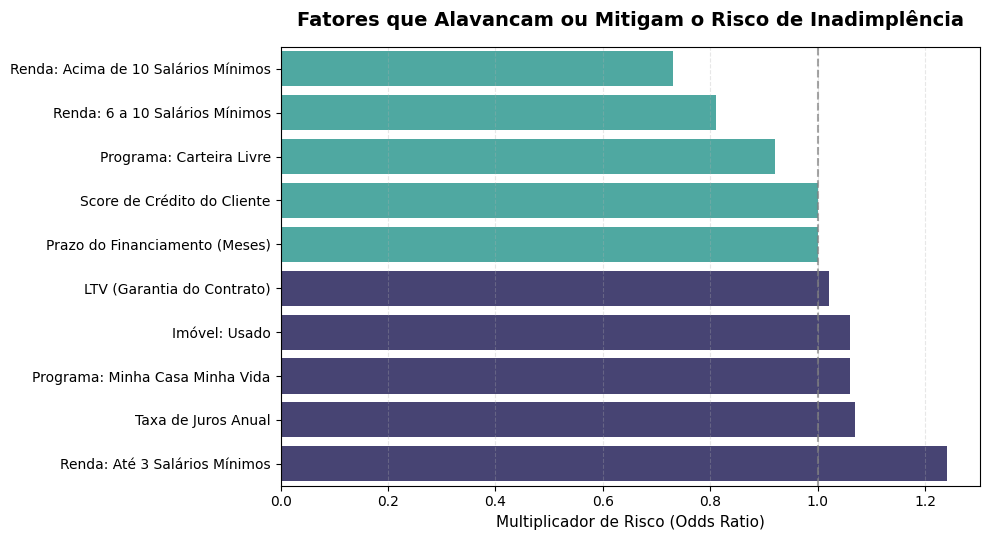

In [24]:
mapeamento_nomes = {
    "C(faixa_renda)[T.Até 3 SM]": "Renda: Até 3 Salários Mínimos",
    "C(faixa_renda)[T.6 a 10 SM]": "Renda: 6 a 10 Salários Mínimos",
    "C(faixa_renda)[T.Acima de 10 SM]": "Renda: Acima de 10 Salários Mínimos",
    "tx_juros_anual": "Taxa de Juros Anual",
    "C(programa_social)[T.MCMV]": "Programa: Minha Casa Minha Vida",
    "C(programa_social)[T.Livre]": "Programa: Carteira Livre",
    "C(tipo_imovel)[T.Usado]": "Imóvel: Usado",
    "ltv": "LTV (Garantia do Contrato)",
    "prazo_meses": "Prazo do Financiamento (Meses)",
    "score_credito_contratacao": "Score de Crédito do Cliente",
}

# Chamando a função
plot_odds_ratio(odds_ratio, mapeamento_nomes)

In [25]:
# Forecast da Inadimplência, Modelagem SARIMAX para previsão da taxa de inadimplência dos próximos 6 meses.


"""
A constatação técnica do modelo SARIMAX reforça que o desemprego é o principal termômetro da inadimplência nesta carteira. O coeficiente negativo
(-0,0122) e estatisticamente significativo (p = 0,029) evidencia um comportamento contracíclico: quando o desemprego aumenta, o banco endurece as
políticas de concessão, reduzindo o risco futuro. Em contrapartida, variáveis como Selic acumulada e componentes sazonais não apresentaram relevância
estatística, mostrando que o custo do dinheiro e padrões de calendário não explicam diretamente a volatilidade da inadimplência. O insight estratégico
é claro: o risco de crédito está mais sensivelmente atrelado à capacidade de geração de emprego e renda do mercado de trabalho do que ao nível da taxa
básica de juros ou às flutuações sazonais. Para o comitê de risco, isso consolida o desemprego como variável-chave na calibração das safras futuras e
na definição de políticas de mitigação.

"""
# Chamando a função
modelo = fit_sarimax(df_forecast)

C:\Users\Windows\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                    fl_inadimplente   No. Observations:                   35
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                  90.281
Date:                            Sat, 23 May 2026   AIC                           -166.562
Time:                                    09:09:03   BIC                           -158.925
Sample:                                         0   HQIC                          -164.763
                                             - 35                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
selic_12m             0.0026      0.002      1.447      0.148      -0.001       0.006
tx_desemprego_

In [26]:
# =========================================================
# PREVISÃO DOS PRÓXIMOS 6 MESES
# =========================================================


'''
A projeção do modelo SARIMAX indica que a inadimplência da carteira deve permanecer relativamente estável nos próximos meses, com leve tendência de
redução após o início da série projetada. As estimativas se concentram na faixa entre 4% e 5%, sugerindo um comportamento controlado mesmo diante das
condições macroeconômicas consideradas. O insight estratégico é que, embora o risco não desapareça, o patamar atual demonstra resiliência da carteira,
reforçando a importância de manter políticas de monitoramento e mitigação ativas para sustentar essa estabilidade e evitar que pressões externas 
revertam a tendência de controle.

'''

# Chamando a função
previsao = forecast_sarimax(modelo, df_forecast)
print(previsao)

35    5.17
36    5.31
37    5.18
38    4.70
39    4.00
40    4.26
Name: predicted_mean, dtype: float64


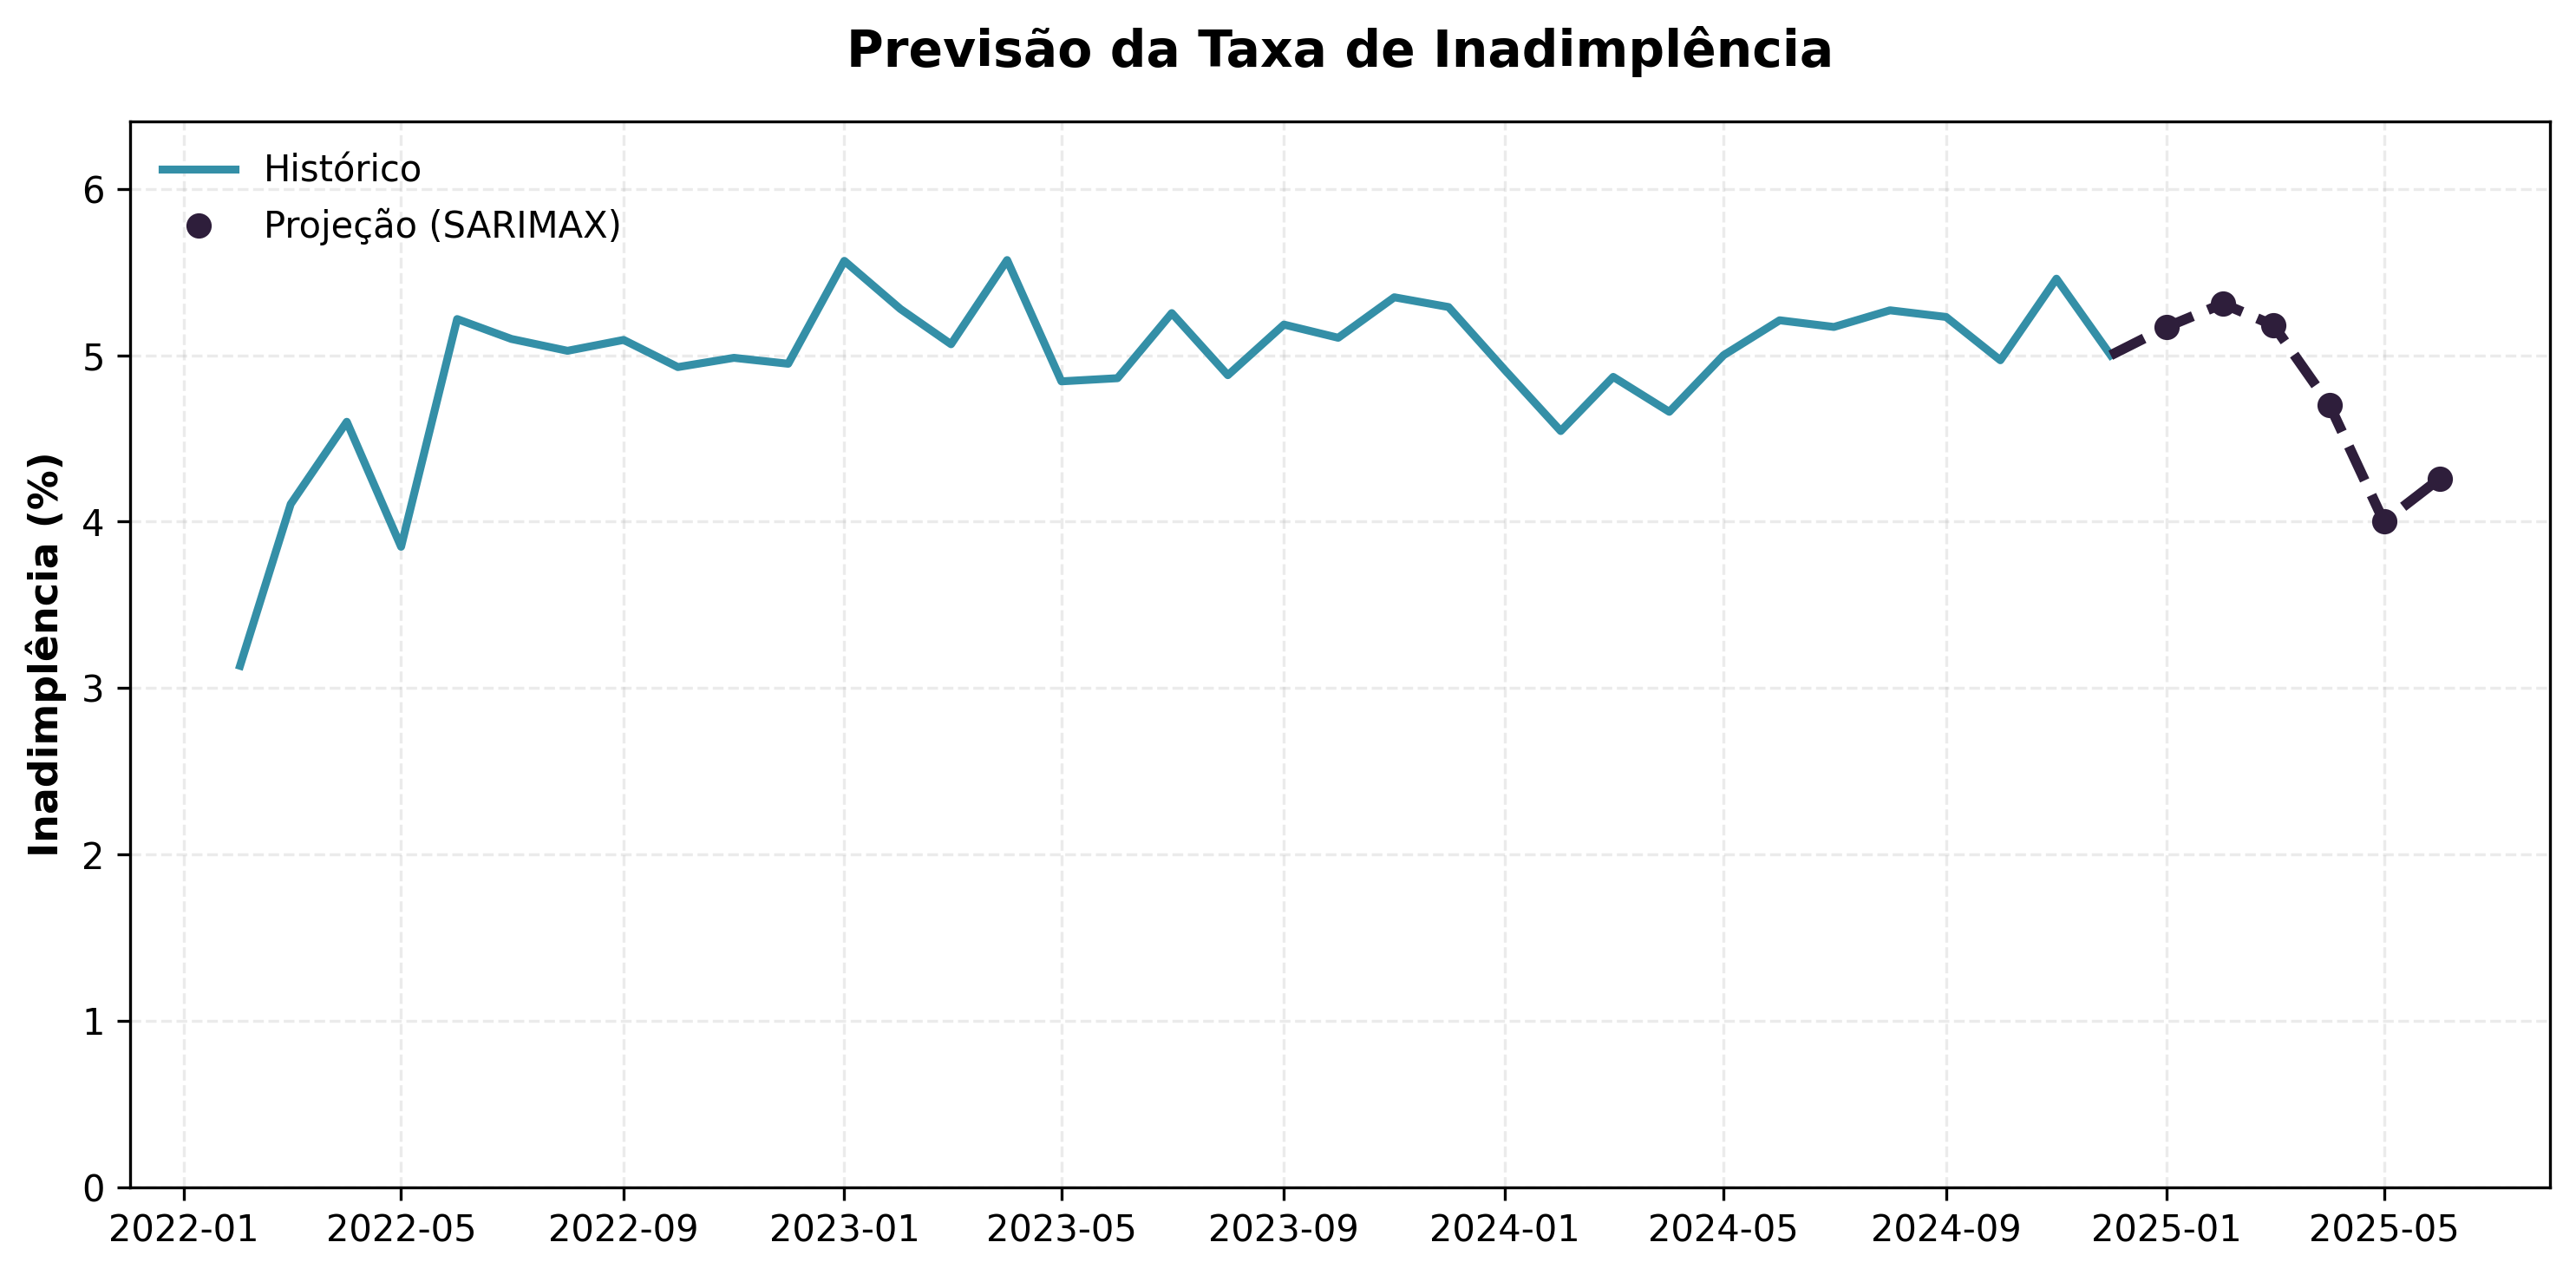

In [27]:
# Chamando a função
exibir_grafico_previsao_inadimplencia(df_forecast, previsao)

# Conclusão e Recomendações
---


## 1. O que aprendemos?
A análise da carteira habitacional revela um **mercado de crédito altamente sensível ao cenário macroeconômico**.  
- **Score de crédito isolado tem baixo poder preditivo**, exigindo integração com variáveis comportamentais e macroeconômicas.  
- **Contratos com alto LTV e juros elevados** são os mais vulneráveis, pois pressionam a renda familiar.  
- O risco não está restrito a programas sociais específicos, mas sim a fatores sistêmicos como inflação e desemprego.  

---

## 2. O que isso significa para o negócio?
A instituição enfrenta uma **fronteira crítica entre estabilidade e deterioração da carteira**:  
- 🔹 **Lucro:** reforçar políticas de precificação por risco e explorar clientes de maior renda, mais resilientes.  
- 🔹 **Risco:** manter contratos com baixo valor de entrada e juros altos sem mitigação, ampliando perdas.  
- O desafio estratégico é **equilibrar concessão de crédito com sustentabilidade financeira**, evitando que choques externos comprometam a carteira.

---

# Recomendações Práticas

- 🔹 **Aperfeiçoar critérios de concessão**  
  Travar limites de LTV para clientes de baixa renda e aplicar juros diferenciados conforme risco.  

- 🔹 **Integrar variáveis macroeconômicas ao modelo de crédito**  
  Incorporar inflação, desemprego e renda real como fatores decisivos na análise de risco.  

- 🔹 **Reposicionar políticas de cobrança e renegociação**  
  Focar em clientes mais expostos (até 6 SM) com estratégias de renegociação preventiva.  

---

# Próximos Passos e Limitações

1. **Expandir base de dados**  
   Incluir informações sobre cancelamentos, renegociações e fidelidade para prever risco futuro.  

2. **Investir em modelos preditivos de inadimplência**  
   Utilizar granularidade por faixa de renda e região, permitindo decisões mais cirúrgicas.  

🔹 **Limitação:** Os insights refletem dados até 2025; mudanças regulatórias e novas dinâmicas econômicas podem alterar o cenário.  

---

# Insights Estratégicos

- 🔹 Baixa renda + juros altos = **risco máximo.**  
- 🔹 Desemprego é o principal termômetro da inadimplência.
- 🔹 Score de crédito sozinho não basta. 
- 🔹 Estabilidade futura depende de políticas de mitigação e monitoramento contínuo.
